In [1]:
from astroquery.mast import Observations
import pandas as pd
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import BarycentricTrueEcliptic
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib import pyplot as plt
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground

def_telescope='JWST'
%run /home/hemanth/jupyter/utils/ImProc_for_MOD.ipynb

In [2]:
obs_1177 = Observations.query_criteria(obs_collection='JWST', proposal_id='1177',filters='F1500W')
obs_1177
# no aparece pq es TRAPPIST-1B
# tmb usa MIRI/SLITLESS

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str7,str4,str7,str10,str4,str6,str8,str11,str54,str41,float64,float64,str10,str17,int64,float64,float64,float64,float64,float64,str42,float64,str4,str3,int64,str115,str68,str73,str6,bool,float64,str9,str9
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1B,Star; Exoplanet Systems; Exoplanets; M dwarfs; M stars,jw01177011001_03101_00001-seg005_mirimage,346.62830409344167,-5.0444419562908145,timeseries,"Greene, Thomas P.",2,59895.67479704676,59895.85639515046,15690.076,13500.0,16500.0,MIRI observations of transiting exoplanets,60261.06854161,1177,GTO,--,POLYGON 346.609986527 -5.039467155 346.639989701 -5.03007276 346.64968374 -5.059965021 346.619818039 -5.069619139,mast:JWST/product/jw01177011001_03101_00001-seg005_mirimage_ramp.jpg,mast:JWST/product/jw01177011001_03101_00001-seg005_mirimage_rateints.fits,PUBLIC,False,nan,100856489,739134524
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1B,Star; Exoplanet Systems; Exoplanets; M dwarfs; M stars,jw01177011001_03101_00001-seg006_mirimage,346.62830409344167,-5.0444419562908145,timeseries,"Greene, Thomas P.",2,59895.67479704676,59895.85639515046,15690.076,13500.0,16500.0,MIRI observations of transiting exoplanets,60261.06908564,1177,GTO,--,POLYGON 346.609986527 -5.039467155 346.639989701 -5.03007276 346.64968374 -5.059965021 346.619818039 -5.069619139,mast:JWST/product/jw01177011001_03101_00001-seg006_mirimage_ramp.jpg,mast:JWST/product/jw01177011001_03101_00001-seg006_mirimage_rateints.fits,PUBLIC,False,nan,100856491,739134537
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1B,Star; Exoplanet Systems; Exoplanets; M dwarfs; M stars,jw01177011001_03101_00001-seg001_mirimage,346.62830409344167,-5.0444419562908145,timeseries,"Greene, Thomas P.",2,59895.67479704676,59895.85639515046,15690.076,13500.0,16500.0,MIRI observations of transiting exoplanets,60261.06857633,1177,GTO,--,POLYGON 346.609986527 -5.039467155 346.639989701 -5.03007276 346.64968374 -5.059965021 346.619818039 -5.069619139,mast:JWST/product/jw01177011001_03101_00001-seg001_mirimage_ramp.jpg,mast:JWST/product/jw01177011001_03101_00001-seg001_mirimage_rateints.fits,PUBLIC,False,nan,100856494,739134550
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1B,Star; Exoplanet Systems; Exoplanets; M dwarfs; M stars,jw01177011001_03101_00001-seg002_mirimage,346.62830409344167,-5.0444419562908145,timeseries,"Greene, Thomas P.",2,59895.67479704676,59895.85639515046,15690.076,13500.0,16500.0,MIRI observations of transiting exoplanets,60261.06841429,1177,GTO,--,POLYGON 346.609986527 -5.039467155 346.639989701 -5.03007276 346.64968374 -5.059965021 346.619818039 -5.069619139,mast:JWST/product/jw01177011001_03101_00001-seg002_mirimage_ramp.jpg,mast:JWST/product/jw01177011001_03101_00001-seg002_mirimage_rateints.fits,PUBLIC,False,nan,100856493,739134563
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1B,Star; Exoplanet Systems; Exoplanets; M dwarfs; M stars,jw01177011001_03101_00001-seg010_mirimage,346.62830409344167,-5.0444419562908145,timeseries,"Greene, Thomas P.",2,59895.67479704676,59895.85639515046,15690.076,13500.0,16500.0,MIRI observations of transiting exoplanets,60261.06782406,1177,GTO,--,POLYGON 346.609986527 -5.039467155 346.639989701 -5.03007276 346.64968374 -5.059965021 346.619818039 -5.069619139,mast:JWST/product/jw01177011001_03101_00001-seg010_mirimage_ramp.jpg,mast:JWST/product/jw01177011001_03101_00001-seg010_mirimage_rateints.fits,PUBLIC,False,nan,100856485,739134578
science,JWST,CALJWST,MIRI/IMAGE,JWST,F1500W,INFRARED,TRAPPIST-1B,Star; Exoplanet Systems; Exoplanets; M dwarfs; M stars,jw01177011001_03101_00001-

In [3]:
import numpy
def on_array(func):#,*args,**kwargs):
    def newfunc(n,*args,**kwargs):
        if type(n)==str or type(n)==numpy.str_:
            return func(n,*args,**kwargs)
        if (hasattr(n, "__len__")):
            return [func(m,*args,**kwargs) for m in n]
        return func(n,*args,**kwargs)
    return newfunc

def np_array(func):
    def newfunc(*args,**kwargs):
        return numpy.array(func(*args,**kwargs))
    return newfunc

@np_array
@on_array
def get_split(st,string,index):
    ext=st.split(string)
    if len(ext)==0:
        return ""
    else:
        return ext[index]

## Return a filter for all those that have that extension
@np_array
@on_array
def get_typefilter(*args):
    st,string=args
    ext=st.split('.')
    if len(ext)==0:
        return False
    if ext[-1] == string:
        return True
    return False

## Return a filter for all those that have that extension
@np_array
@on_array
def get_grepfilter(*args):
    st,string=args
    if string in st:
        return True
    return False


## get only
import os
link_str = 'https://mast.stsci.edu/api/v0.1/Download/file?uri=mast:JWST/product/'
@on_array
def mast_down(string):
    print('Start download %s'%(string))
    os.system('curl %s%s -o %s'%(link_str,string,string))

In [4]:
c_icrs = SkyCoord(ra=obs_1177['s_ra']*u.degree, dec=obs_1177['s_dec']*u.degree, frame='icrs')
c_bte = c_icrs.transform_to('barycentrictrueecliptic')
lats = np.array([c.lat.value for c in c_bte])

filt = (lats>-10) * (lats<10)

ecl_filts = obs_1177[np.where(filt)[0]]


In [5]:
#ecl_filts_public = ecl_filts[(ecl_filts['proposal_id'] == '1644')]#&(ecl_filts['dataRights']=='PUBLIC')]
dataprod= Observations.get_product_list(ecl_filts)
dataprod

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str9,str4,str10,str41,str57,str1,str77,str9,str28,str13,str1,str7,str6,str4,str59,int64,str9,str6,int64,str6
100380724,JWST,timeseries,jw01177007001_03101_00001-seg002_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw01177007001_gs-acq1_2022312024753_stream.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,--,1177,jw01177007001_gs-acq1_2022312024753_stream.fits,406080,100380724,PUBLIC,1,F1500W
100380724,JWST,timeseries,jw01177007001_03101_00001-seg002_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw01177007001_gs-acq1_2022312024753_uncal.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,--,1177,jw01177007001_gs-acq1_2022312024753_uncal.fits,420480,100380724,PUBLIC,1,F1500W
100380724,JWST,timeseries,jw01177007001_03101_00001-seg002_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw01177007001_gs-acq1_2022312024839_stream.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,--,1177,jw01177007001_gs-acq1_2022312024839_stream.fits,406080,100380724,PUBLIC,1,F1500W
100380724,JWST,timeseries,jw01177007001_03101_00001-seg002_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw01177007001_gs-acq1_2022312024839_uncal.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,--,1177,jw01177007001_gs-acq1_2022312024839_uncal.fits,420480,100380724,PUBLIC,1,F1500W
100380724,JWST,timeseries,jw01177007001_03101_00001-seg002_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw01177007001_gs-acq1_2022312024753_cal.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,1.17.1,1177,jw01177007001_gs-acq1_2022312024753_cal.fits,1284480,100380724,PUBLIC,2,F1500W
100380724,JWST,timeseries,jw01177007001_03101_00001-seg002_mirimage,FGS1 guide star acquisition,S,mast:JWST/product/jw01177007001_gs-acq1_2022312024839_cal.fits,AUXILIARY,--,GS-ACQ1,--,CALJWST,1.17.1,1177,jw01177007001_gs-acq1_2022312024839_cal.fits,1284480,100380724,PUBLIC,2,F1500W
100380724,JWST,timeseries,jw01177007001_03101_00001-seg002_mirimage,FGS2 guide star acquisition,S,mast:JWST/product/jw01177007001_gs-acq2_2022312024754_stream.fits,AUXILIARY,--,GS-ACQ2,--,CALJWST,--,1177,jw01177007001_gs-acq2_2022312024754_stream.fits,34560,100380724,PUBLIC,1,F1500W
100380724,JWST,timeseries,jw01177007001_03101_00001-seg002_mirimage,FGS2 guide star acquisition,S,mast:JWST/product/jw01177007001_gs-acq2_2022312024754_uncal.fits,AUXILIARY,--,GS-ACQ2,--,CALJWST,--,1177,jw01177007001_gs-acq2_2022312024754_uncal.fits,48960,100380724,PUBLIC,1,F1500W
100380724,JWST,timeseries,jw01177007001_03101_00001-seg002_mirimage,FGS2 guide star acquisition,S,mast:JWST/product/jw01177007001_gs-acq2_2022312024840_stream.fits,AUXILIARY,--,GS-ACQ2,--,CALJWST,--,1177,jw01177007001_gs-acq2_2022312024840_stream.fits,34560,100380724,PUBLIC,1,F1500W


In [6]:
# In data_products_by_obs select only fits that are calints
filt_down = get_typefilter(dataprod['dataURI'],'fits') * get_grepfilter(dataprod['dataURI'],'calints')
sum(filt_down)

50

In [7]:
# # DESCARGA DE ARCHIVOS
# list2down = get_split(dataprod['dataURI'][filt_down],'/',-1)
# mast_down(list2down)

In [7]:
import glob
filenames = glob.glob("jw01177*miri*calints*fits")
len(filenames)
from astropy.io import fits as fits

filenames.sort()
fitsfiles = [fits.open(fn) for fn in filenames]

In [8]:
fitsfiles[0][1].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                 1032                                                  
NAXIS2  =                 1024                                                  
NAXIS3  =                   40                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'SCI     '           / extension name                                 
MJD-BEG =    59891.14214063472 / [d] exposure start time in MJD                 
MJD-AVG =   59891.232939686575 / [d] exposure mid-point in MJD                  
MJD-END =    59891.32373873843 / [d] exposure end time in MJD                   
TDB-BEG =    59891.145782848

In [9]:
import pandas as pd
# hk is a dictionary of extensions and header keys
def get_pandas_header(fs, hk={0:['FILTER','OBJECT']}):
    dic={}
    for ext in hk.keys():
        for k in hk[ext]:
            dic[k]= [f[ext].header[k] for f in fs]
    return pd.DataFrame(dic)

In [10]:
df = get_pandas_header(fitsfiles, {0:['TARG_RA','TARG_DEC','FILTER','EXPSTART','EXPEND','EFFEXPTM', 'DETECTOR'],
                                  1: ['CRVAL1', 'CRVAL2']})

df.sort_values('EXPSTART')   

,TARG_RA,TARG_DEC,FILTER,EXPSTART,EXPEND,EFFEXPTM,DETECTOR,CRVAL1,CRVAL2
0,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640
8,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640
7,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640
6,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640
5,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640
9,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640
3,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640
2,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640
1,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640
4,346.628301,-5.044440,F1500W,59891.142141,59891.323739,15690.076,MIRIMAGE,346.628175,-5.044640


In [11]:
# funcion para encontrar indices de los archivos con cierta columna en comun

def obs_idx(data, sort_by, first, last):
    # data: df a ocupar
    # sort_by: el parámetro en el que se ordena df (str)
    # first, last: primer y último archivo buscado
    return np.array(data.sort_values(sort_by).index[first:last])

In [12]:
obsidx_1 = obs_idx(df,'EXPSTART',0,10)
obsidx_2 = obs_idx(df,'EXPSTART',10,20)
obsidx_3 = obs_idx(df,'EXPSTART',20,30)
obsidx_4 = obs_idx(df,'EXPSTART',30,40)
obsidx_5 = obs_idx(df,'EXPSTART',40,50)

print(obsidx_1,obsidx_2,obsidx_3,obsidx_4,obsidx_5)
obsidx_1.sort(),obsidx_2.sort(),obsidx_3.sort(),obsidx_4.sort(),obsidx_5.sort()
print(obsidx_1,obsidx_2,obsidx_3,obsidx_4,obsidx_5)

[0 8 7 6 5 9 3 2 1 4] [40 47 46 45 44 43 42 41 48 49] [10 11 12 18 13 14 15 16 17 19] [20 24 29 21 22 23 25 26 27 28] [32 39 38 37 36 35 30 33 31 34]
[0 1 2 3 4 5 6 7 8 9] [40 41 42 43 44 45 46 47 48 49] [10 11 12 13 14 15 16 17 18 19] [20 21 22 23 24 25 26 27 28 29] [30 31 32 33 34 35 36 37 38 39]


In [14]:
## sacar el fondo de cada imagen

# fits_nobkg = []

# for i in range(50):
#     obs_nobkg = []
#     for j in range(len(fitsfiles[i][1].data)):
#         nobkg = remove_background(fitsfiles[i][1].data[j],size=(15,15))
#         obs_nobkg.append(nobkg)
#     fits_nobkg.append(obs_nobkg)


In [16]:
# # guardar algo a archivo

# import pickle
# f = open(b'fits_nobkg_1177.pkl','wb')
# pickle.dump(fits_nobkg, f)


In [13]:
# leer algo de archivo
import pickle
f = open('fits_nobkg_1177.pkl','br')
fits_nobkg = pickle.load(f)


In [14]:
len(fits_nobkg)

50

In [15]:
fits_nobkg_trimm = []

for i in range(50):  # itera archivos
    files = []
    for j in range(len(fits_nobkg[i])):  # itera la imagen del archivo
        im = fits_nobkg[i][j][:,350:]
        files.append(im)
    fits_nobkg_trimm.append(files)
    

In [16]:
def arch_sum(files,obsnum):
    
    sumas = []
    
    if obsnum == 1:
        for i in range(10):
            sumas.append(np.sum(files[obsidx_1[i]], axis=0))
    elif obsnum == 2:
        for i in range(10):
            sumas.append(np.sum(files[obsidx_2[i]], axis=0))
    elif obsnum == 3:
        for i in range(10):
            sumas.append(np.sum(files[obsidx_3[i]], axis=0))
    elif obsnum == 4:
        for i in range(10):
            sumas.append(np.sum(files[obsidx_4[i]], axis=0))
    elif obsnum == 5:
        for i in range(10):
            sumas.append(np.sum(files[obsidx_5[i]], axis=0))
    
    return sumas

In [17]:
obs_1b = arch_sum(fits_nobkg_trimm,1)
obs_2b = arch_sum(fits_nobkg_trimm,2)
obs_3b = arch_sum(fits_nobkg_trimm,3)
obs_4b = arch_sum(fits_nobkg_trimm,4)
obs_5b = arch_sum(fits_nobkg_trimm,5)

1 2


<IPython.core.display.Javascript object>


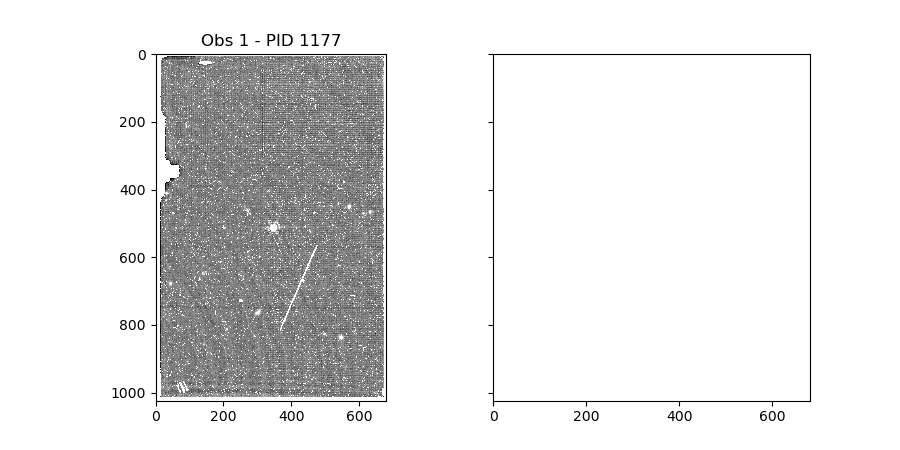

1 2


<IPython.core.display.Javascript object>


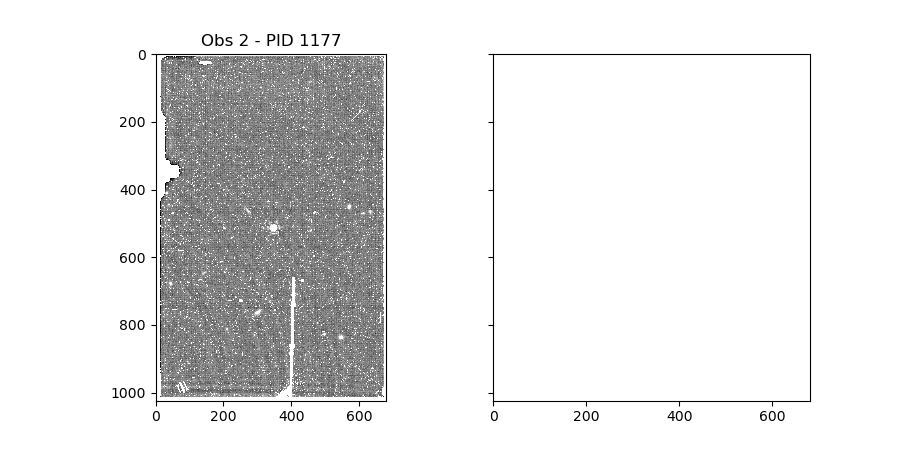

1 2


<IPython.core.display.Javascript object>


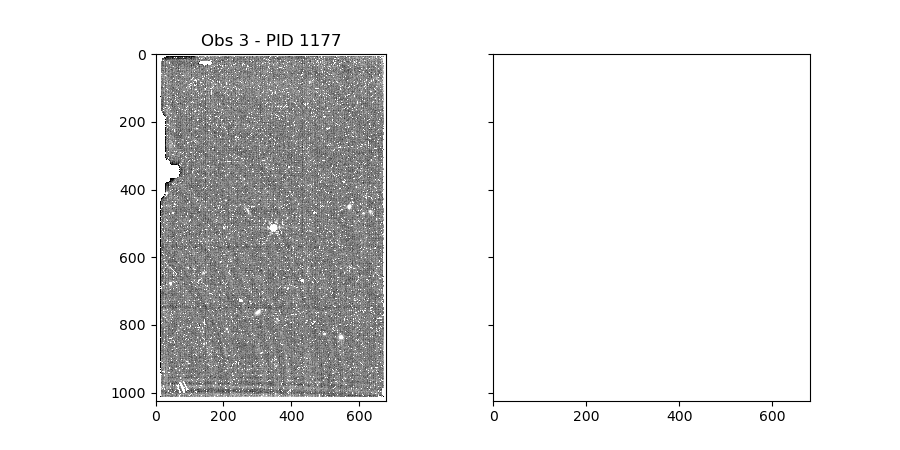

1 2


<IPython.core.display.Javascript object>


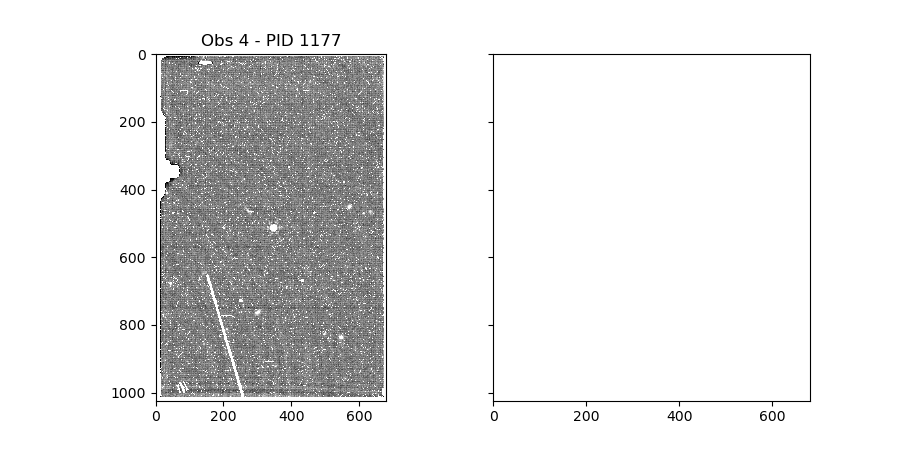

1 2


<IPython.core.display.Javascript object>


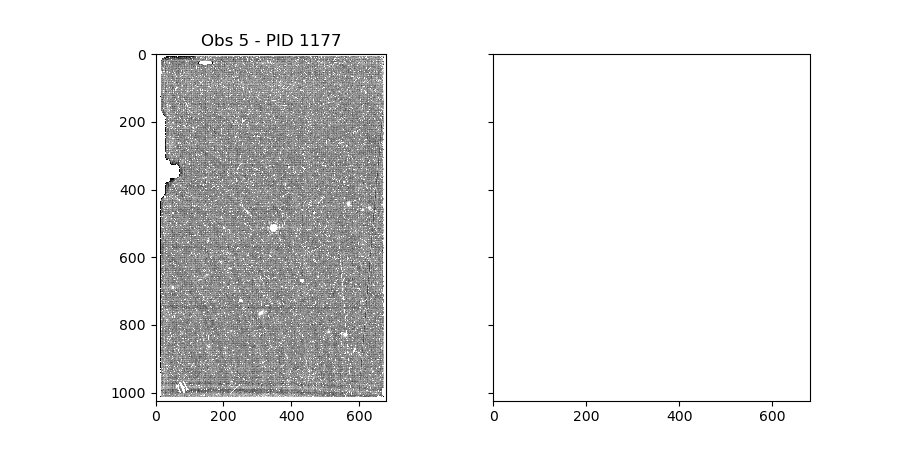

Text(0.5, 1.0, 'Obs 5 - PID 1177')

In [23]:
fig1,axes1 = ds9_comp([np.sum(obs_1b,axis=0)])
fig2,axes2 = ds9_comp([np.sum(obs_2b,axis=0)])
fig3,axes3 = ds9_comp([np.sum(obs_3b,axis=0)])
fig4,axes4 = ds9_comp([np.sum(obs_4b,axis=0)])
fig5,axes5 = ds9_comp([np.sum(obs_5b,axis=0)])

axes1[0].set_title('Obs 1 - PID 1177')
axes2[0].set_title('Obs 2 - PID 1177')
axes3[0].set_title('Obs 3 - PID 1177')
axes4[0].set_title('Obs 4 - PID 1177')
axes5[0].set_title('Obs 5 - PID 1177')

1 3


<IPython.core.display.Javascript object>


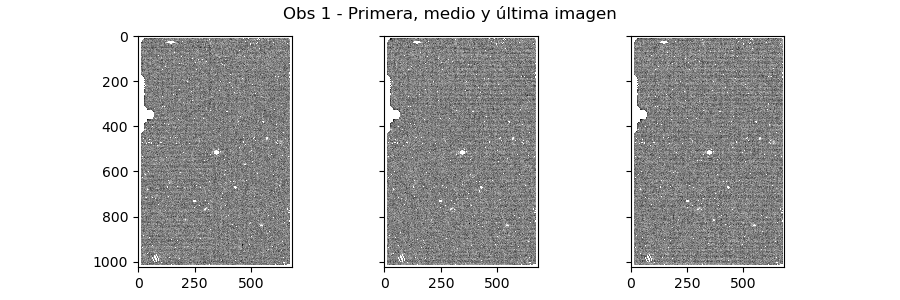

Text(0.5, 0.98, 'Obs 1 - Primera, medio y última imagen')

In [20]:
#encontre una funcion en el notebook improc

fig1_paso, axes1_paso = ds9_comp([fits_nobkg_trimm[obsidx_1[0]][0],fits_nobkg_trimm[obsidx_1[4]][20],
                                  fits_nobkg_trimm[obsidx_1[-1]][-1]],ncols=3)

fig1_paso.suptitle('Obs 1 - Primera, medio y última imagen')

1 3


<IPython.core.display.Javascript object>


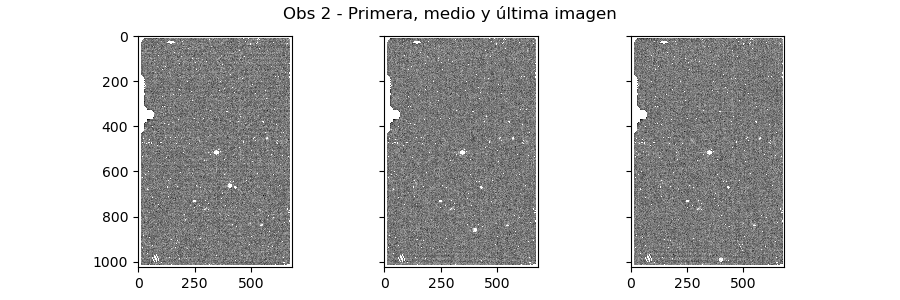

Text(0.5, 0.98, 'Obs 2 - Primera, medio y última imagen')

In [21]:
fig2_paso, axes2_paso = ds9_comp([fits_nobkg_trimm[obsidx_2[0]][0],fits_nobkg_trimm[obsidx_2[1]][20],
                                  fits_nobkg_trimm[obsidx_2[2]][20]],ncols=3)
# en los primeros 3 archivos esta el asteroide
fig2_paso.suptitle('Obs 2 - Primera, medio y última imagen')

6 5


<IPython.core.display.Javascript object>


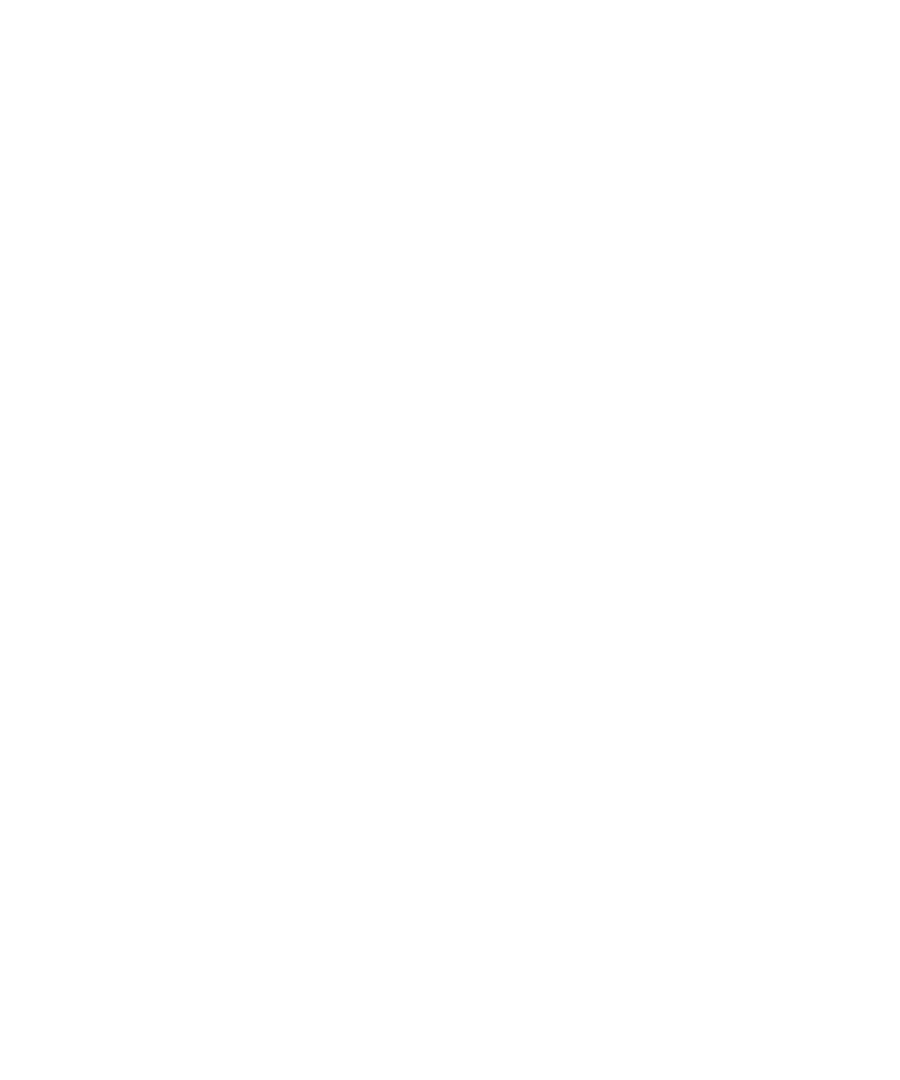

(<Figure size 900x1080 with 30 Axes>,
 array([[<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>]], dtype=object))

In [22]:
ds9_comp([fits_nobkg[obsidx_2[i]][j] for i in range(0,10) for j in [0,10,-1]], ncols=5)

1 3


<IPython.core.display.Javascript object>


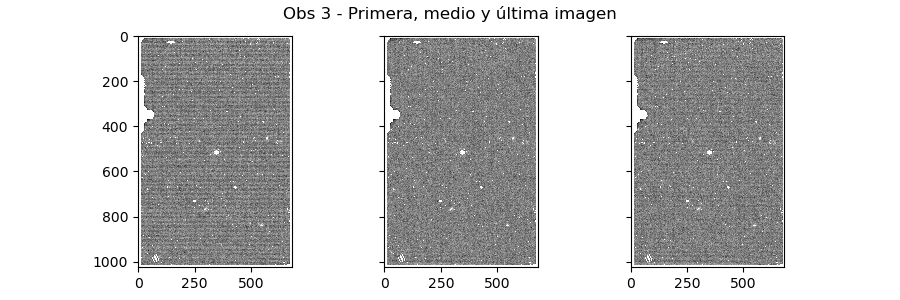

Text(0.5, 0.98, 'Obs 3 - Primera, medio y última imagen')

In [23]:
fig3_paso, axes3_paso = ds9_comp([fits_nobkg_trimm[obsidx_3[0]][0],fits_nobkg_trimm[obsidx_3[4]][20],
                                  fits_nobkg_trimm[obsidx_3[-1]][-1]],ncols=3)

fig3_paso.suptitle('Obs 3 - Primera, medio y última imagen')

1 3


<IPython.core.display.Javascript object>


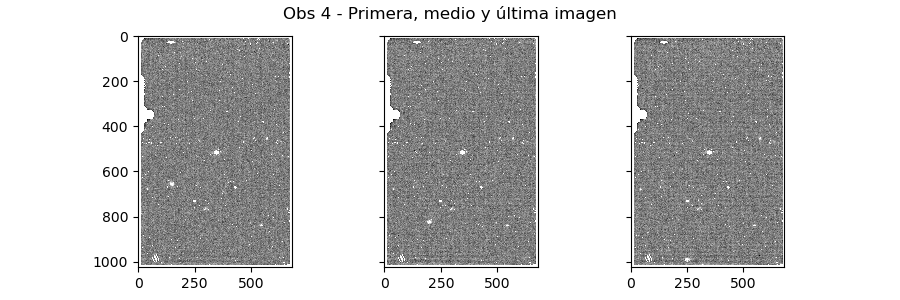

Text(0.5, 0.98, 'Obs 4 - Primera, medio y última imagen')

In [24]:
fig4_paso, axes4_paso = ds9_comp([fits_nobkg_trimm[obsidx_4[0]][0],fits_nobkg_trimm[obsidx_4[1]][20],
                                  fits_nobkg_trimm[obsidx_4[2]][-1]],ncols=3)

# nuevamente lo saqué a mano, no sé que onda el orden

fig4_paso.suptitle('Obs 4 - Primera, medio y última imagen')

6 5


<IPython.core.display.Javascript object>


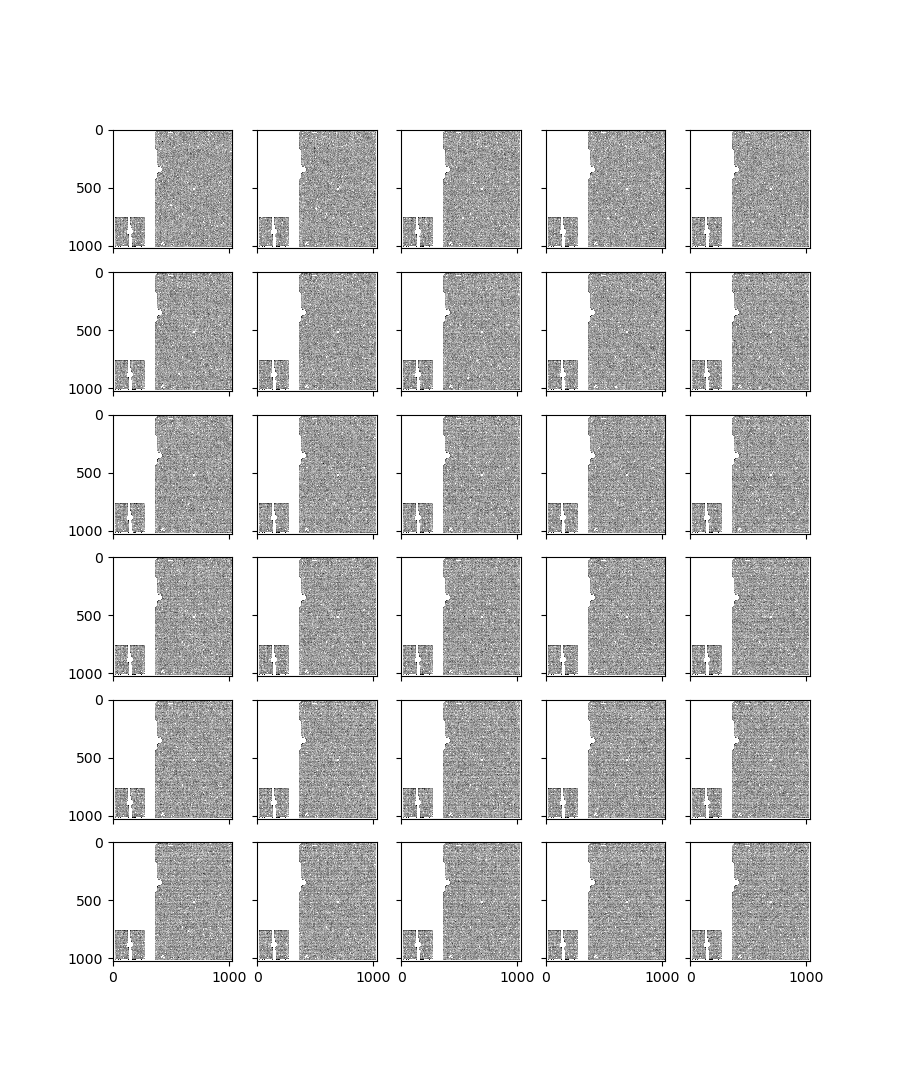

(<Figure size 900x1080 with 30 Axes>,
 array([[<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>]], dtype=object))

In [25]:
ds9_comp([fits_nobkg[obsidx_4[i]][j] for i in range(0,10) for j in [0,10,-1]], ncols=5)

1 3


<IPython.core.display.Javascript object>


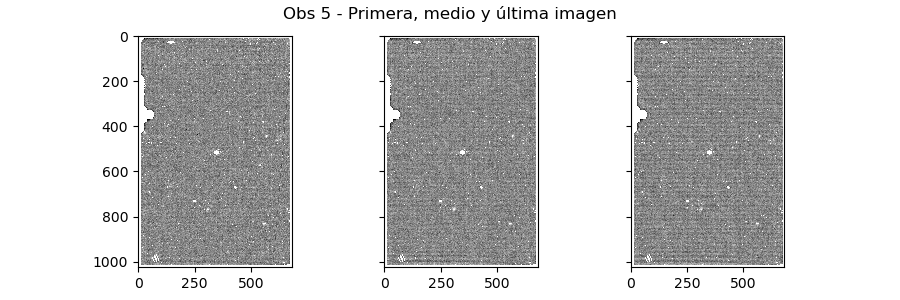

Text(0.5, 0.98, 'Obs 5 - Primera, medio y última imagen')

In [26]:
fig5_paso, axes5_paso = ds9_comp([fits_nobkg_trimm[obsidx_5[0]][0],fits_nobkg_trimm[obsidx_5[4]][20],
                                  fits_nobkg_trimm[obsidx_5[-1]][-1]],ncols=3)

fig5_paso.suptitle('Obs 5 - Primera, medio y última imagen')

In [24]:
# quitar NaN de las imagenes, reemplazar con valor mayor a máximo

def change_nan(x,nan=0):
    shape = x.shape
    x = x.ravel()
    x[np.isnan(x)] = nan
    x = x.reshape(shape)
    return x

In [25]:
fits_nonan = []

for i in range(len(fits_nobkg_trimm)):
    nonan = change_nan(np.array(fits_nobkg_trimm[i]),nan=500.0)
    fits_nonan.append(nonan)
        

5 2


<IPython.core.display.Javascript object>


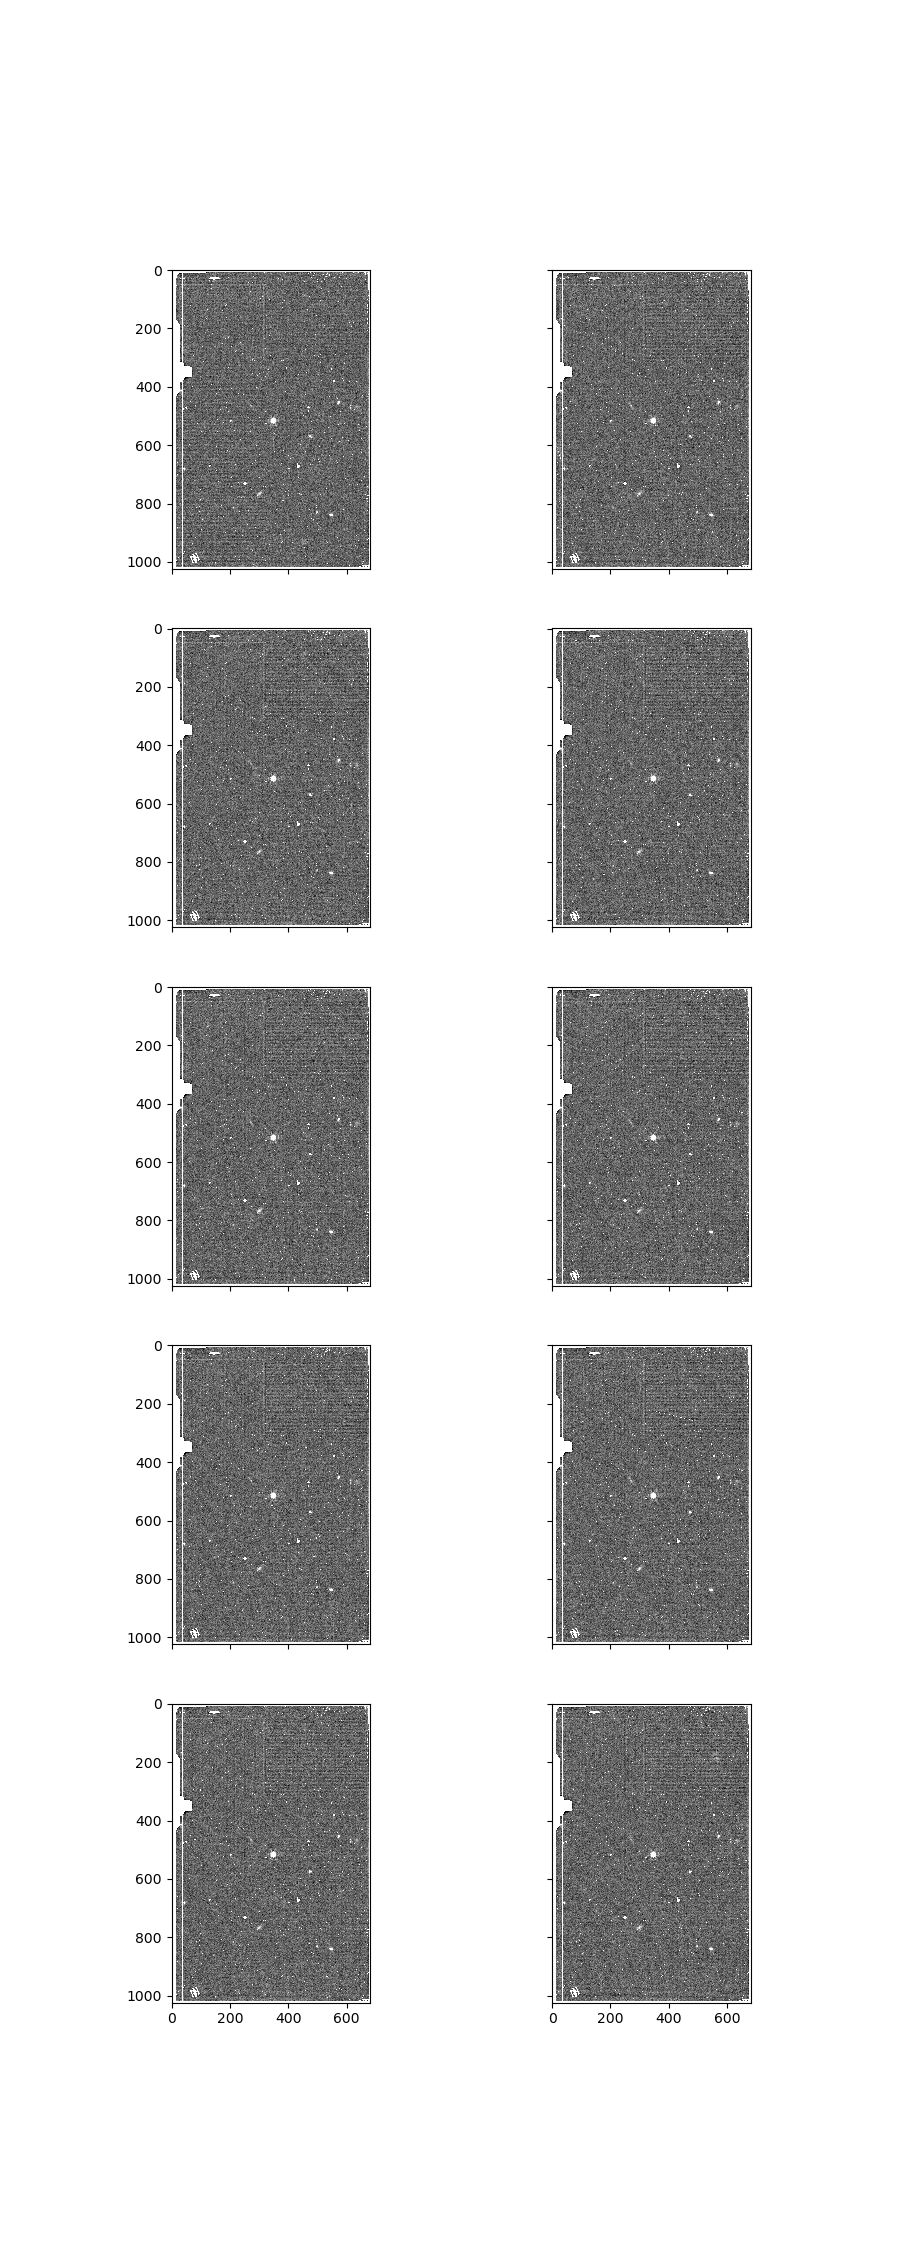

(<Figure size 900x2250 with 10 Axes>,
 array([[<AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>]], dtype=object))

In [31]:
ds9_comp(fits_nonan[0][:10])

In [26]:
sub = []
for stare in range(len(fits_nonan)):
    sky = np.median(fits_nonan[stare], axis=0)
    avg = np.mean(fits_nonan[stare], axis=0) 

    sub.append(avg-sky)        
    

9 6


<IPython.core.display.Javascript object>


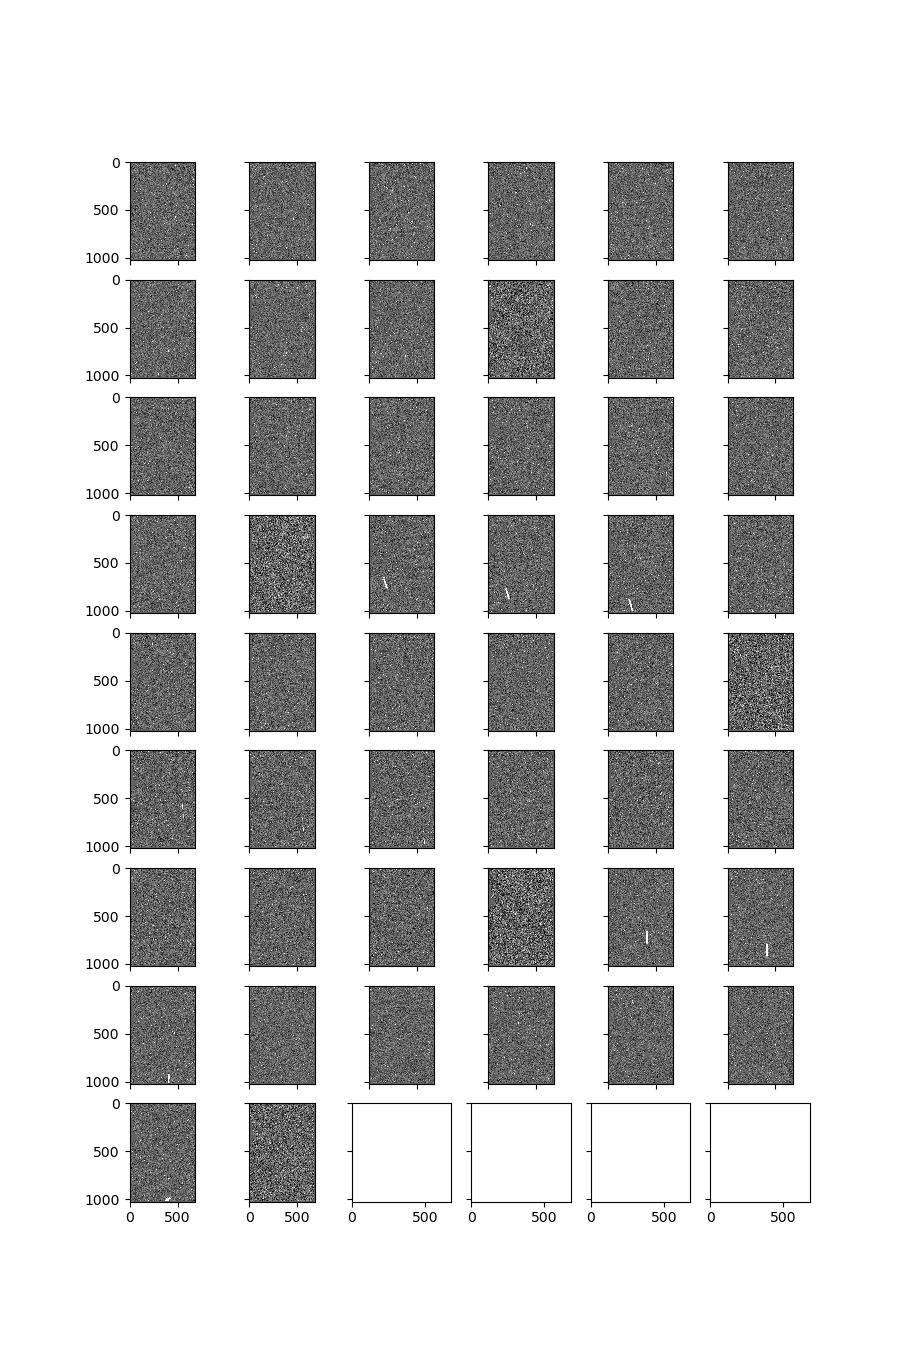

(<Figure size 900x1350 with 54 Axes>,
 array([[<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:>, <AxesSubplot:>, <

In [33]:
ds9_comp(sub,ncols=6)

1 2


<IPython.core.display.Javascript object>


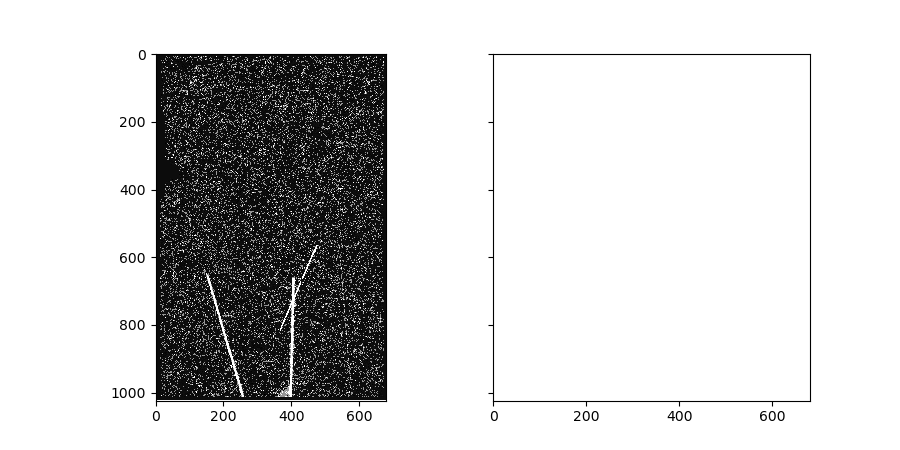

1 2


<IPython.core.display.Javascript object>


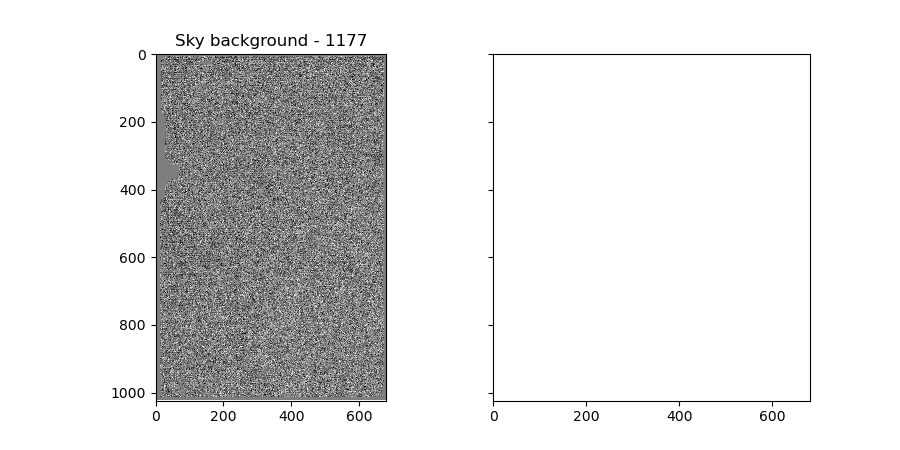

Text(0.5, 1.0, 'Sky background - 1177')

In [28]:
ds9_comp([np.mean(sub,axis=0)])
fig_sky, ax_sky = ds9_comp([np.median(sub,axis=0)])
                            
ax_sky[0].set_title('Sky background - 1177')